# **You Wanna Live Where?**

## Objectives

* Exploratory Data Analysis on the countries, Austria, Belgium and Ireland, as part of the larger scope of Western Europe.

## Inputs

* The verified dataset - cost_of_living_verified.csv

* Libraries containing the tools to do EDA and render visualisations, pandas, numpy, matplotlib, seaborn.

## Outputs

* Visualisations 

* Evalutaions of the three countries in isolation against the "Affordibility Rule", to be then taken into the larger context of Western Europe.




---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Capston Projects\\Hackathon\\Hackathon_Where_You_Wanna_Live\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Capston Projects\\Hackathon\\Hackathon_Where_You_Wanna_Live'

# Import Block

Libraries required to perfrom operations and visualisations

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [5]:
# Load the dataset into a dataframe
df_verified = pd.read_csv("Dataset/Verified/cost_of_living_verified.csv")

# Verify the dataframe
df_verified.head(5)

,country,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year,period,continent
0,Bermuda,135.8,108.2,123.5,143.4,147.5,101.3,2026,year,North America
1,Cayman Islands,115.6,76.1,97.9,124.0,101.5,149.6,2026,year,North America
2,US Virgin Islands,111.3,46.8,82.5,127.4,94.8,89.8,2026,year,North America
3,Switzerland,110.7,51.5,84.3,109.7,111.3,170.6,2026,year,Europe
4,Solomon Islands,102.3,19.5,65.4,64.8,46.0,12.6,2026,year,Oceania


To reduce unecessary cell ouput, the three target countries for this notebook will be segragated into another dataframe. 

In [6]:
# Storing the three countries into a variable to work with
my_countries = ["Austria", "Belgium", "Ireland"]

# Declaring the dataframes values
my_df = df_verified[df_verified["country"].isin(my_countries)].copy()

# Verify country selection
my_df.head(10).sort_index(ascending=True)

,country,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year,period,continent
18,Austria,71.3,25.1,50.7,72.6,71.5,120.0,2026,year,Europe
19,Ireland,70.6,43.8,58.7,68.8,76.6,114.4,2026,year,Europe
24,Belgium,68.6,23.8,48.6,66.4,80.7,124.2,2026,year,Europe
170,Austria,60.7,22.0,43.6,62.2,59.7,107.1,2025,year,Europe
172,Ireland,59.8,39.0,50.6,56.9,65.8,108.9,2025,year,Europe
181,Belgium,56.5,19.3,40.1,54.6,67.1,116.1,2025,year,Europe
312,Austria,66.8,23.7,46.4,64.8,59.0,84.4,2024,year,Europe
313,Ireland,66.5,47.3,57.4,58.9,65.9,82.0,2024,year,Europe
321,Belgium,63.0,21.4,43.3,56.1,67.8,90.7,2024,year,Europe
457,Ireland,70.5,44.4,58.0,55.8,71.9,82.6,2023,year,Europe


---

# Section 1 - Overview and Individual Inspections

We'll start with focused look at the three countries statistics together before deeper, individual investigation.

In [7]:
my_df.describe()

,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,71.522222,31.362963,52.618519,63.225926,74.329630,93.114815,2022.000000
std,7.246343,9.400292,6.741835,5.979426,9.113591,14.223564,2.631174
min,56.500000,19.300000,40.100000,54.500000,59.000000,73.800000,2018.000000
25%,66.650000,24.450000,49.050000,58.550000,67.450000,82.150000,2020.000000
50%,71.300000,27.100000,50.700000,62.200000,71.900000,91.200000,2022.000000
75%,75.700000,41.950000,57.700000,67.450000,80.950000,98.800000,2024.000000
max,85.400000,47.300000,67.000000,76.800000,93.200000,124.200000,2026.000000


The inital observation shows that we have total value count of 27, allowing for an even 9 entries for each country. Cost of living values have a moderate variation while rent and local purchasing power display heavier variability. Let's break it down and look further into the seperate countries.

In [8]:
# Make a groupby() comparison
country_summ = (
    my_df.groupby("country")[
        ["cost_of_living_index",
         "rent_index",
         "cost_of_living_plus_rent_index",
         "groceries_index",
         "restaurant_price_index",
         "local_purchasing_power_index"
         ]
    ]
    .agg(["mean", "median", "std"]).round(2)
)
country_summ

cost_of_living_index              rent_index               \
                        mean median   std       mean median   std   
country                                                             
Austria                70.56   71.0  5.90      25.90   26.8  2.54   
Belgium                70.32   71.8  8.06      24.31   25.4  2.82   
Ireland                73.69   75.3  7.93      43.88   43.9  2.66   

        cost_of_living_plus_rent_index              groceries_index         \
                                  mean median   std            mean median   
country                                                                      
Austria                          49.56   50.5  3.93           66.13   65.6   
Belgium                          48.67   49.6  5.18           61.62   60.9   
Ireland                          59.63   59.2  4.69           61.92   59.1   

              restaurant_price_index               \
          std                   mean median   std   
country                                             
Austria  5.71                  67.19   68.1  5.64   
Belgium  6.35                  78.03   80.1  8.63   
Ireland  5.38                  77.77   80.4  8.81   

        local_purchasing_power_index                
                                mean median    std  
country                                             
Austria                        92.89   91.2  14.27  
Belgium                        95.78   94.5  15.73  
Ireland                        90.68   82.6  13.85

The follow up descriptive statistics display noticeable differnce bewteen the three countries. Ireland has the the higher average cost of living and higher rent values, which is driving up their cost of living plus rent index. Austria and Belgium appear to have similar overall living costs, however their expenditures differ. Austria has higher grocery costs where Belgium has the greater restaurant cost. Additionally, Belgium also has the higher average local purchasing power with Ireland having the lowest.

These inital findings indicate towards the affordibility not being determined by living costs alone, suggesting that purchasing power and individual cost components should also be considered

---

# Section 2 - Trend over Time

Starting with the cost of living index, let's see it's development over time. 

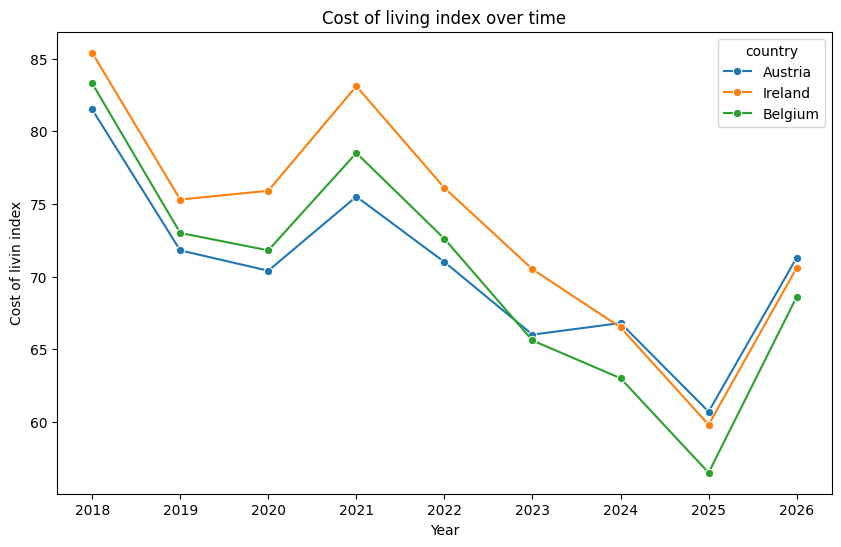

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=my_df,
    x="year",
    y="cost_of_living_index",
    hue="country",
    marker="o"
)

plt.title("Cost of living index over time")
plt.xlabel("Year")
plt.ylabel("Cost of living index")

plt.show()

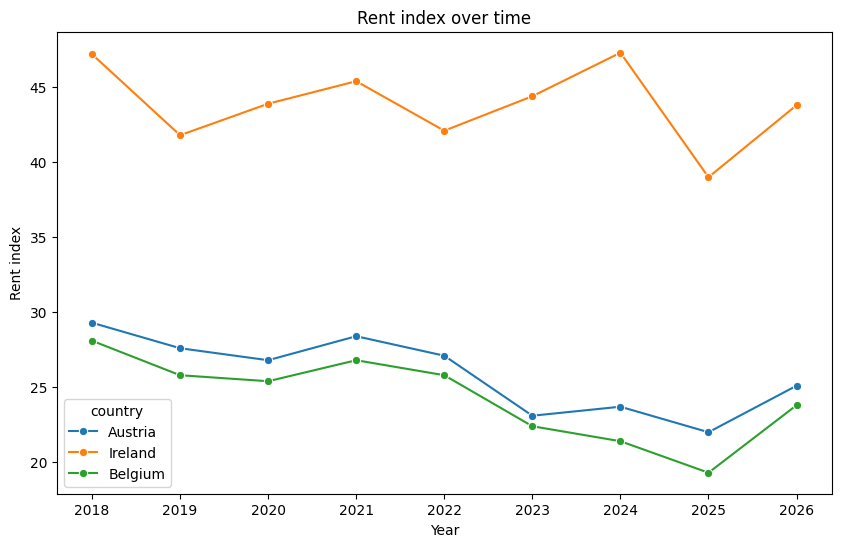

In [11]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=my_df,
    x="year",
    y="rent_index",
    hue="country",
    marker="o"
)

plt.title("Rent index over time")
plt.xlabel("Year")
plt.ylabel("Rent index")

plt.show()

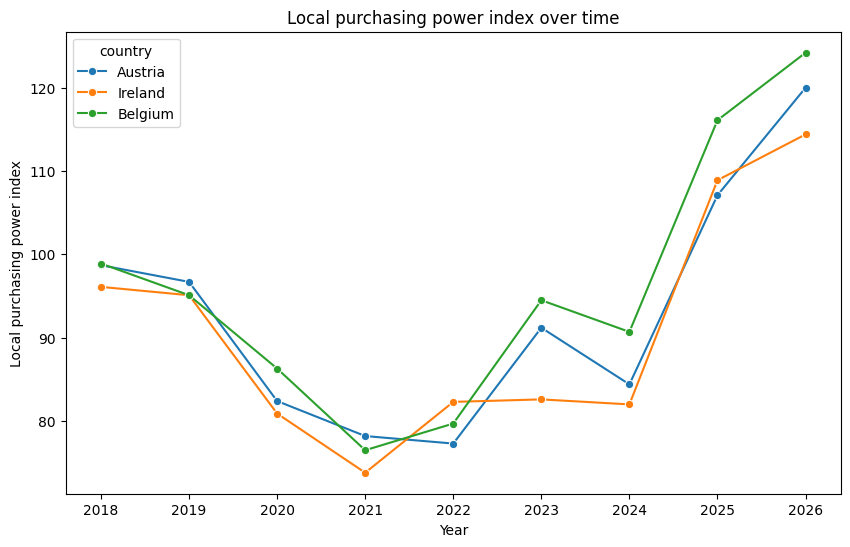

In [12]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=my_df,
    x="year",
    y="local_purchasing_power_index",
    hue="country",
    marker="o"
)

plt.title("Local purchasing power index over time")
plt.xlabel("Year")
plt.ylabel("Local purchasing power index")

plt.show()